# Jasmin Experiments

Notebook orchestration only. Shared implementation lives in `src/`.

ROADMAP: 
Baseline PatchCore          0.40  (done)
+ multi-view fusion (done)         
+ DINOv2 backbone           0.41     (done, meh)     
+ supervised patch MLP      0.79  (done, very good)
+ MLP + DRAEM (done - bad, too slow)
+ Test-Time Augmentation — easiest, do it first (done, good)
No retraining. Average MLP predictions over 4-8 augmented versions of each test image (same D4/Klein-4 logic as training). Estimated +1-2%. Gets you to ~0.81.
+ FastFlow ensemble — highest expected gain
Normalizing flow on top of WideResNet50 features. The key insight: MLP's weakness is unseen defect types (generalization gap 0.91→0.79). FastFlow catches any deviation from the normal feature distribution regardless of defect type — different failure mode, no whole-object elevation. Ensemble via global ranks like we tried with PatchCore. Estimated +2-3%.
+ Finer spatial resolution via out_indices: [1, 2, 3] — pure config change, no code needed.
Currently using layers 2+3 → 28×28 grid (8px/patch). Adding layer 1 shifts to 56×56 grid (4px/patch). The MLP already handles variable grid sizes — _build_feature_extractor probes it automatically. Feat dim becomes 1792 instead of 1536. This directly improves pixel-level localization, which is exactly what AP measures. Same training time since normal_patches_per_image=50 is still a subsample.

+ Ensemble of two MLPs with different backbones — train a second MLP using resnet50 or efficientnet_b4 instead of wide_resnet50_2. Both are discriminative and spatially precise (no whole-object elevation). Different feature spaces = genuinely different failure modes. Ensemble via global ranks.

Semi-supervision improvements:
- Feature normalization — the MLP gets raw backbone features without normalizing by the training distribution. This is critical for MLP stability and performance. Should subtract the mean and divide by std of normal patch features before training.

- Focal loss instead of fixed pos_weight — with ~1% anomalous patches, a fixed weight is fragile. Focal loss dynamically focuses on hard examples.

- Data augmentation on anomalous patches — 235 examples is very few. Flipping/rotating anomalous patches during training effectively multiplies the anomaly dataset.

- The deepest issue — combining with PatchCore: The MLP sees raw features with no "normality reference". The most principled approach is to also feed PatchCore's k-NN distances as input features. The MLP then has both:
-- How far this patch is from the normal distribution (PatchCore)
-- What the patch looks like (backbone features)
- Hard negative mining — after first training pass, find the hardest normal patches (high MLP score but label=0) and oversample them in subsequent epochs.

The better architecture: instead of training from scratch, use PatchCore scores as starting point and train the MLP to calibrate/refine them using the labeled anomalies. Much less data needed.

First wideresnet patch MLP: 0.90 (on 20% test set)

Augmentation (4 rot + 2 rot for symmetric classes): 0.91

TTA: mean aggregation:  47 anomalies + 3801 normals (held-out)
Pixel AP:    0.8093
Image AP:    0.5643
Pixel AUROC: 0.9966

TTA: max augmentation: 47 anomalies + 3801 normals (held-out)
Pixel AP:    0.6704
Image AP:    0.3789
Pixel AUROC: 0.9963

TTA: logit augmentation: 47 anomalies + 3801 normals (held-out)
Pixel AP:    0.8036
Image AP:    0.5625
Pixel AUROC: 0.9960

TTA: sigma 2.0 instead of 4.0
Pixel AP:    0.8037
Image AP:    0.5757
Pixel AUROC: 0.9963

Image-wise MLP+FF ensemble:

- 0.4: Pixel AP:    0.9101
Image AP:    0.8089
Pixel AUROC: 0.9960


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.common.config import load_config
from src.common.data import SpacepressoDataModule
from src.common.evaluation import evaluate_predictions
from src.common.paths import resolve_path
from src.common.seed import set_seed
from src.common.submission import SubmissionWriter, validate_submission
from src.common.training import ExperimentRunner
from src.common.validation import make_validation_split
from src.common.visualization import show_predictions
from src.methods import get_method_class

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")
print("PyTorch:", torch.__version__)

CUDA available: True
Device: NVIDIA GeForce RTX 4060 Ti
PyTorch: 2.3.1


In [3]:
# supervised MLP (primary method)
config = load_config(ROOT / "configs/supervised_patch_mlp/jasmin_mlp.yaml")

set_seed(config.get("seed", 42))

local_data = ROOT / "data" / "spacepresso"
if local_data.exists():
    config["data"]["root"] = str(local_data)
config["data"]["load_images"] = False

# --- Toggles ---
SAVE_FILE              = True
NO_BACKGROUND          = True
NO_BACKGROUND_TRAINING = True
VIEW_WISE              = True
MULTI_VIEW_FUSION      = True
MULTI_VIEW_CONSISTENCY = True
CONSISTENCY_ALPHA      = 0.5
ENSEMBLE               = False
ENSEMBLE_MLP_WEIGHT    = 0.8
FAST_FLOW              = False
FF_GATE_ALPHA          = 0.4    # 0=pure MLP, 1=fully gated by FF image score
TTA                    = True
BG_DILATION            = 16
BG_THRESHOLD           = 0.20
BG_THRESHOLD_PER_CLASS = {
    "class_01": 0.40,
    "class_02": 0.30,
    "class_08": 0.40,
}

def get_bg_threshold(class_name, view_id=None):
    if view_id and (class_name, view_id) in BG_THRESHOLD_PER_CLASS:
        return BG_THRESHOLD_PER_CLASS[(class_name, view_id)]
    return BG_THRESHOLD_PER_CLASS.get(class_name, BG_THRESHOLD)

if NO_BACKGROUND_TRAINING:
    config["method"]["no_background"]          = True
    config["method"]["bg_threshold"]           = BG_THRESHOLD
    config["method"]["bg_dilation"]            = BG_DILATION
    config["method"]["bg_threshold_per_class"] = BG_THRESHOLD_PER_CLASS

if VIEW_WISE:
    config["method"]["view_wise"] = True

dm = SpacepressoDataModule(**config["data"])
train_good      = dm.load_train_good()
train_anomalies = dm.load_train_anomalies()
test            = dm.load_test()
print({"train_good": len(train_good), "train_anomalies": len(train_anomalies), "test": len(test)})

DEV_CLASSES = None
if DEV_CLASSES:
    train_good      = [s for s in train_good      if s.class_name in DEV_CLASSES]
    train_anomalies = [s for s in train_anomalies if s.class_name in DEV_CLASSES]
    test            = [s for s in test            if s.class_name in DEV_CLASSES]
    print(f"Filtered to {DEV_CLASSES}")

# --- Anomaly split: type-based OOD holdout (1 type per class held out) ---
import random as _rng
from collections import defaultdict

_rng.seed(config.get("seed", 42))
_type_groups = defaultdict(list)
for s in train_anomalies:
    _type_groups[(s.class_name, s.anomaly_type)].append(s)

_class_types = defaultdict(list)
for (cls, atype) in _type_groups:
    _class_types[cls].append(atype)

train_anomalies_val = []
train_anomalies_fit = []
for cls in sorted(_class_types):
    types = sorted(_class_types[cls])
    # Prefer hidden types ("Localized visual anomaly") — closest to Kaggle test distribution
    _HIDDEN = {"class_03": "anomaly_02", "class_04": "anomaly_03",
               "class_06": "anomaly_01", "class_07": "anomaly_03", "class_08": "anomaly_06"}
    val_type = _HIDDEN.get(cls, types[-1])
    for (c, atype), samples in _type_groups.items():
        if c != cls: continue
        if atype == val_type:
            train_anomalies_val.extend(samples)
        else:
            train_anomalies_fit.extend(samples)

print(f"Type-based OOD split: {len(train_anomalies_fit)} fit / {len(train_anomalies_val)} val")
for cls in sorted(_class_types):
    types = sorted(_class_types[cls])
    print(f"  {cls}: train={types[:-1]}  val={types[-1]}")

# --- Normal train/val split ---
VAL_GOOD_FRACTION = 0.2
_shuffled_good = _rng.sample(train_good, len(train_good))
_n_good_val = max(1, int(len(_shuffled_good) * VAL_GOOD_FRACTION)) if VAL_GOOD_FRACTION > 0 else 0
train_good_val = _shuffled_good[:_n_good_val]
train_good_fit = _shuffled_good[_n_good_val:]
print(f"Normal split: {len(train_good_fit)} fit / {len(train_good_val)} val")


In [4]:
# old validation split
# --- Anomaly train/val split ---
#VAL_ANOMALY_FRACTION = 0.0
#import random as _rng
#_rng.seed(config.get("seed", 42))
#_shuffled = _rng.sample(train_anomalies, len(train_anomalies))
#_n_val = max(1, int(len(_shuffled) * VAL_ANOMALY_FRACTION)) if VAL_ANOMALY_FRACTION > 0 else 0
#train_anomalies_val = _shuffled[:_n_val]
#train_anomalies_fit = _shuffled[_n_val:]
#print(f"Anomaly split: {len(train_anomalies_fit)} fit / {len(train_anomalies_val)} val")

## Background extraction

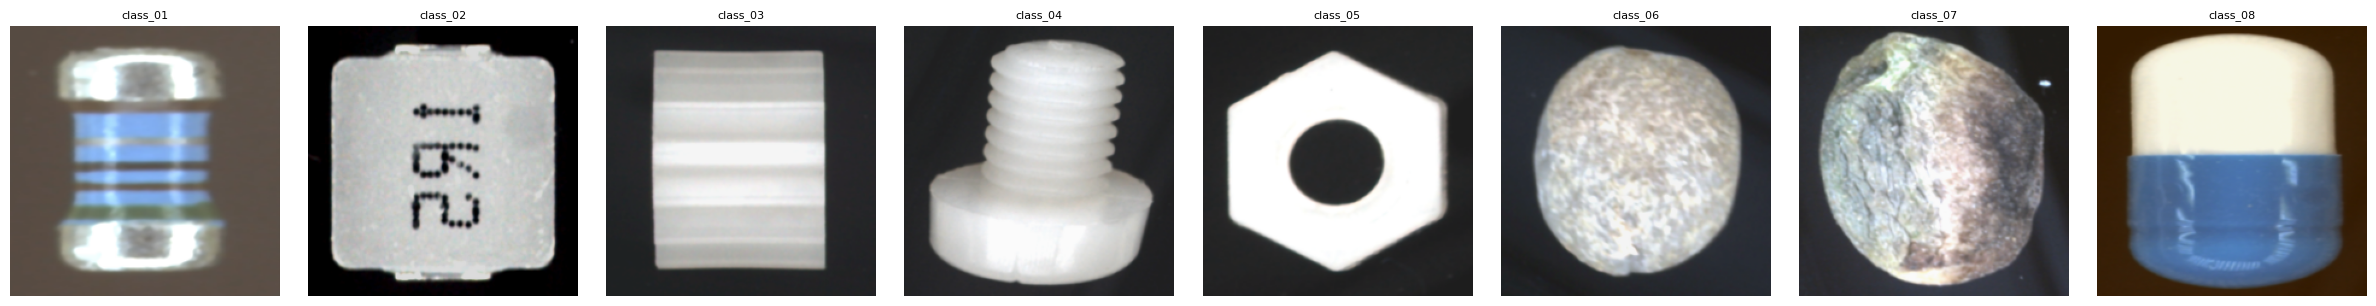

In [5]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import numpy as np

classes = sorted({s.class_name for s in train_good})
fig, axes = plt.subplots(1, len(classes), figsize=(3 * len(classes), 3))
if len(classes) == 1:
    axes = [axes]
for ax, cls in zip(axes, classes):
    sample = next(s for s in train_good if s.class_name == cls)
    img = np.array(PILImage.open(sample.image_path).convert("RGB"))
    ax.imshow(img)
    ax.set_title(cls, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

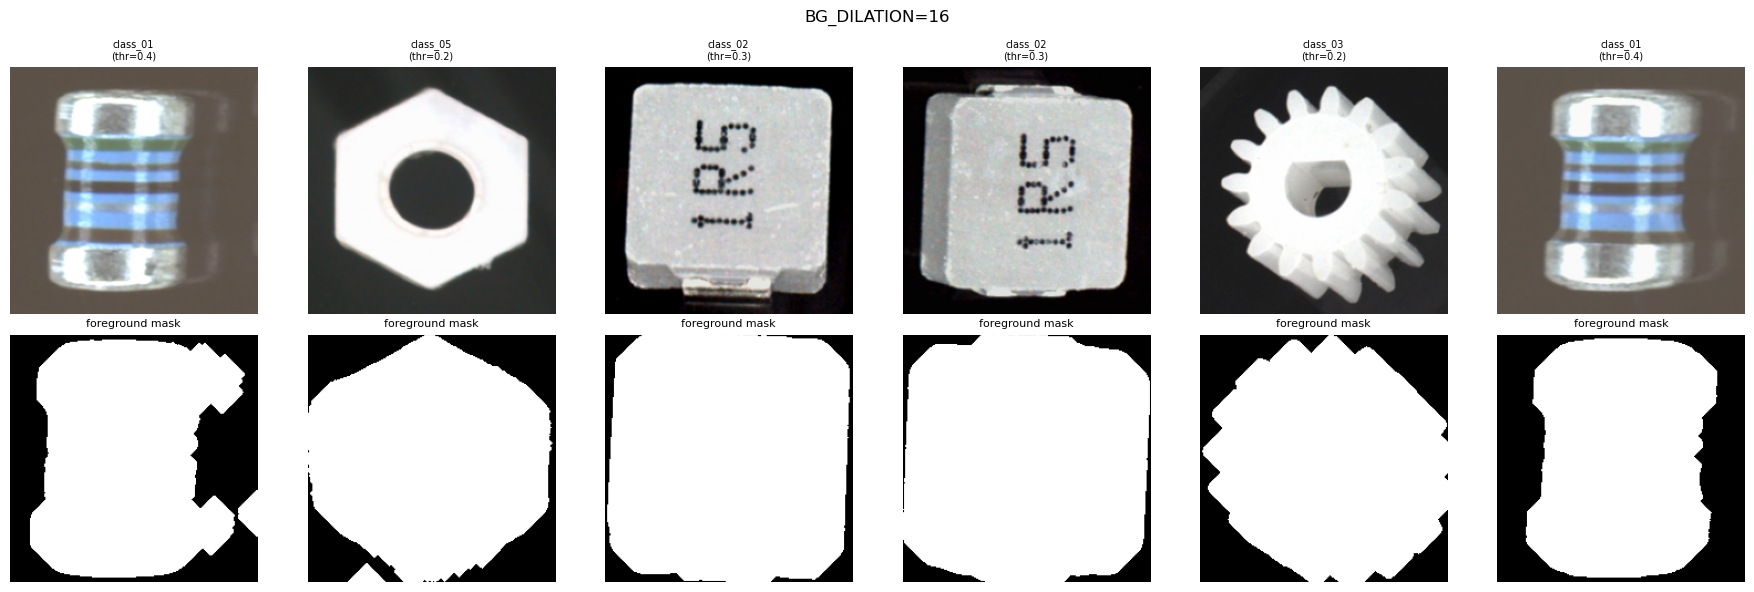

In [6]:
# Sanity check: visualize foreground masks on a few training images
if NO_BACKGROUND:
    import random
    import matplotlib.pyplot as plt
    from PIL import Image as PILImage
    import numpy as np
    from scipy.ndimage import binary_fill_holes, binary_dilation as _bdilate

    def _preview_foreground_mask(image_np, threshold, dilation):
        gray = image_np.mean(axis=2)
        fg = binary_fill_holes(gray > threshold)
        if dilation > 0:
            fg = _bdilate(fg, iterations=dilation)
        return fg.astype(np.float32)

    samples = random.sample(train_good, 6)
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for col, sample in enumerate(samples):
        img = np.array(PILImage.open(sample.image_path).convert("RGB").resize((config["data"]["image_size"], config["data"]["image_size"]))) / 255.0
        threshold = get_bg_threshold(sample.class_name)
        mask = _preview_foreground_mask(img, threshold, BG_DILATION)
        axes[0, col].imshow(img)
        axes[0, col].set_title(f"{sample.class_name}\n(thr={threshold})", fontsize=7)
        axes[0, col].axis("off")
        axes[1, col].imshow(mask, cmap="gray", vmin=0, vmax=1)
        axes[1, col].set_title("foreground mask", fontsize=8)
        axes[1, col].axis("off")
    plt.suptitle(f"BG_DILATION={BG_DILATION}")
    plt.tight_layout()
    plt.show()

## Training

In [7]:
# --- Train supervised MLP ---
if train_good_fit and test and (not FAST_FLOW or ENSEMBLE):
    Method = get_method_class(config["method"]["name"])
    runner = ExperimentRunner(Method(config), config)
    runner.fit(train_good_fit + train_anomalies_fit)
    mlp_predictions = runner.method.predict(test, tta=TTA)
    show_predictions(test, mlp_predictions, n=3)
else:
    runner = None
    mlp_predictions = {}
    print("MLP skipped (FastFlow standalone mode)")


c:\Users\PC\anaconda3\envs\adl_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Backbone: wide_resnet50_2 | grid=56×56 | feat_dim=1792

Fitting MLP for class_01: 2117 images (20 anomalous)


  Patch dataset: 76,428 patches | 6,948 anomalous (9.09%) | ratio=10:1
  Focal loss: alpha=0.909, gamma=2.0
  [class_01] MLP epoch 01/35 | loss=0.00700 | lr=9.98e-04
  [class_01] MLP epoch 02/35 | loss=0.00134 | lr=9.92e-04
  [class_01] MLP epoch 03/35 | loss=0.00069 | lr=9.82e-04
  [class_01] MLP epoch 04/35 | loss=0.00049 | lr=9.68e-04
  [class_01] MLP epoch 05/35 | loss=0.00036 | lr=9.51e-04
  [class_01] MLP epoch 06/35 | loss=0.00032 | lr=9.29e-04
  [class_01] MLP epoch 07/35 | loss=0.00030 | lr=9.05e-04
  [class_01] MLP epoch 08/35 | loss=0.00025 | lr=8.77e-04
  [class_01] MLP epoch 09/35 | loss=0.00021 | lr=8.46e-04
  [class_01] MLP epoch 10/35 | loss=0.00020 | lr=8.12e-04
  [class_01] MLP epoch 11/35 | loss=0.00019 | lr=7.76e-04
  [class_01] MLP epoch 12/35 | loss=0.00018 | lr=7.37e-04
  [class_01] MLP epoch 13/35 | loss=0.00016 | lr=6.97e-04
  [class_01] MLP epoch 14/35 | loss=0.00013 | lr=6.55e-04
  [class_01] MLP epoch 15/35 | loss=0.00012 | lr=6.12e-04
  [class_01] MLP epoch

  Patch dataset: 215,028 patches | 19,548 anomalous (9.09%) | ratio=10:1
  Focal loss: alpha=0.909, gamma=2.0
  [class_02] MLP epoch 01/35 | loss=0.00279 | lr=9.98e-04
  [class_02] MLP epoch 02/35 | loss=0.00064 | lr=9.92e-04
  [class_02] MLP epoch 03/35 | loss=0.00051 | lr=9.82e-04
  [class_02] MLP epoch 04/35 | loss=0.00049 | lr=9.68e-04
  [class_02] MLP epoch 05/35 | loss=0.00044 | lr=9.51e-04
  [class_02] MLP epoch 06/35 | loss=0.00046 | lr=9.29e-04
  [class_02] MLP epoch 07/35 | loss=0.00047 | lr=9.05e-04
  [class_02] MLP epoch 08/35 | loss=0.00039 | lr=8.77e-04
  [class_02] MLP epoch 09/35 | loss=0.00037 | lr=8.46e-04


KeyboardInterrupt: 

In [ ]:
# --- Train FastFlow (unsupervised) ---
if FAST_FLOW:
    from src.methods.fastflow import Method as FastFlowMethod

    ff_cfg = load_config(ROOT / "configs/fastflow/jasmin_fastflow.yaml")
    ff_cfg["data"]["root"]        = config["data"]["root"]
    ff_cfg["data"]["load_images"] = False

    ff_runner = FastFlowMethod(ff_cfg)
    ff_runner.fit(train_good_fit)   # normals only — fully unsupervised
    fastflow_predictions = ff_runner.predict(test)
    print(f"FastFlow predictions: {len(fastflow_predictions)} images")
else:
    fastflow_predictions = {}


Backbone: wide_resnet50_2 | grid=28×28 | feat_dim=1536

FastFlow fitting class_01: 2600 normal images
  [class_01] epoch 001/100 | loss=29776.2663 | lr=1.00e-03
  [class_01] epoch 010/100 | loss=-81885.0679 | lr=9.76e-04
  [class_01] epoch 020/100 | loss=-97979.5036 | lr=9.05e-04
  [class_01] epoch 030/100 | loss=-117996.4964 | lr=7.94e-04
  [class_01] epoch 040/100 | loss=-132750.3672 | lr=6.55e-04
  [class_01] epoch 050/100 | loss=-149041.2320 | lr=5.01e-04
  [class_01] epoch 060/100 | loss=-167410.1550 | lr=3.46e-04
  [class_01] epoch 070/100 | loss=-182523.8353 | lr=2.07e-04
  [class_01] epoch 080/100 | loss=-192090.8197 | lr=9.64e-05
  [class_01] epoch 090/100 | loss=-199161.1178 | lr=2.54e-05
  [class_01] epoch 100/100 | loss=-201233.3137 | lr=1.00e-06

FastFlow fitting class_02: 2135 normal images
  [class_02] epoch 001/100 | loss=28414.7516 | lr=1.00e-03
  [class_02] epoch 010/100 | loss=-78767.4123 | lr=9.76e-04
  [class_02] epoch 020/100 | loss=-102805.6677 | lr=9.05e-04
  [c

  FastFlow [class_01] done: 465 images


  FastFlow [class_02] done: 800 images


  FastFlow [class_03] done: 790 images


  FastFlow [class_04] done: 745 images


  FastFlow [class_05] done: 225 images


  FastFlow [class_06] done: 1010 images


  FastFlow [class_07] done: 915 images


  FastFlow [class_08] done: 960 images
FastFlow predictions: 5910 images


In [ ]:
# --- Set active predictions ---
print(f"Toggles: TTA={TTA} | FAST_FLOW={FAST_FLOW} | ENSEMBLE={ENSEMBLE} | FF_GATE_ALPHA={FF_GATE_ALPHA}")
import numpy as np
from scipy.stats import rankdata

def _global_ranks(preds_dict):
    """Global percentile ranks across ALL images — never per-image."""
    ids      = sorted(preds_dict.keys())
    flat_all = np.concatenate([preds_dict[iid].reshape(-1).astype(np.float32) for iid in ids])
    ranks    = (rankdata(flat_all, method="average") / len(flat_all)).astype(np.float32)
    n        = preds_dict[ids[0]].size
    return {iid: ranks[i * n : (i + 1) * n].reshape(preds_dict[iid].shape).astype(np.float16)
            for i, iid in enumerate(ids)}

def _ff_image_gate(mlp_preds, ff_preds, alpha):
    """Scale MLP pixel maps by FastFlow image-level score.
    Preserves MLP spatial precision; uses FF only for image-level detection.
    Normal images (low FF score) get suppressed; anomalous ones keep full MLP score.
    """
    ff_img  = {iid: float(ff_preds[iid].max()) for iid in mlp_preds}
    ff_min  = min(ff_img.values())
    ff_max  = max(ff_img.values())
    ff_dr   = ff_max - ff_min if ff_max > ff_min else 1.0
    ff_norm = {iid: (s - ff_min) / ff_dr for iid, s in ff_img.items()}
    return {
        iid: (mlp_preds[iid].astype(np.float32) *
              (1.0 - alpha + alpha * ff_norm[iid])).astype(np.float16)
        for iid in mlp_preds
    }

if FAST_FLOW and ENSEMBLE and fastflow_predictions and mlp_predictions:
    print(f"Image-level gating: alpha={FF_GATE_ALPHA}...")
    predictions = _ff_image_gate(mlp_predictions, fastflow_predictions, FF_GATE_ALPHA)
    print(f"MLP+FF (image-gate): {len(predictions)} predictions")
elif FAST_FLOW and fastflow_predictions:
    predictions = fastflow_predictions
    print(f"FastFlow standalone: {len(predictions)} images")
elif ENSEMBLE and patchcore_predictions and mlp_predictions:
    w_mlp = ENSEMBLE_MLP_WEIGHT
    w_pc  = 1.0 - w_mlp
    print("Computing global ranks (MLP + PatchCore)...")
    mlp_ranked = _global_ranks(mlp_predictions)
    pc_ranked  = _global_ranks(patchcore_predictions)
    predictions = {
        iid: np.clip(
            w_mlp * mlp_ranked[iid].astype(np.float32) +
            w_pc  * pc_ranked[iid].astype(np.float32),
            0.0, 1.0
        ).astype(np.float16)
        for iid in mlp_predictions
    }
    print(f"Ensemble (MLP+PC): {w_mlp:.0%} MLP + {w_pc:.0%} PatchCore -> {len(predictions)} predictions")
else:
    predictions = mlp_predictions
    print(f'MLP{"(TTA)" if TTA else ""}: {len(predictions)} images')


Toggles: TTA=True | FAST_FLOW=True | ENSEMBLE=True | FF_GATE_ALPHA=0.2
Image-level gating: alpha=0.2...
MLP+FF (image-gate): 5910 predictions


In [ ]:
#runner.method.plot_training_history()

In [ ]:
# Background suppression: zero out outer black background in each prediction map
if NO_BACKGROUND and predictions:
    from PIL import Image as PILImage
    from scipy.ndimage import binary_fill_holes, binary_dilation as _bdilate
    import numpy as np

    image_size = config["data"]["image_size"]
    id_to_sample = {s.image_id: s for s in test}

    for img_id, pred in predictions.items():
        sample = id_to_sample[img_id]
        threshold = get_bg_threshold(sample.class_name)
        img = np.array(PILImage.open(sample.image_path).convert("RGB").resize((image_size, image_size))) / 255.0
        fg = binary_fill_holes(img.mean(axis=2) > threshold)
        if BG_DILATION > 0:
            fg = _bdilate(fg, iterations=BG_DILATION)
        predictions[img_id] = pred * fg.astype(np.float32)

    print("Background suppression applied.")

Background suppression applied.


In [ ]:
import numpy as np
from collections import defaultdict

# Build sample→views map from test set
sample_to_views = defaultdict(list)
for s in test:
    sample_to_views[s.sample_id].append(s.image_id)

# --- Multi-view fusion: propagate max score across all 5 views ---
if MULTI_VIEW_FUSION and predictions:
    n_boosted = 0
    for image_ids in sample_to_views.values():
        maps = [predictions[iid] for iid in image_ids if iid in predictions]
        if not maps: continue
        sample_max = max(float(m.max()) for m in maps)
        for iid in image_ids:
            if iid not in predictions: continue
            view_max = float(predictions[iid].max())
            if view_max < sample_max - 1e-6:
                scale = sample_max / max(view_max, 1e-6)
                predictions[iid] = np.clip(predictions[iid] * scale, 0.0, 1.0).astype(predictions[iid].dtype)
                n_boosted += 1
    print(f"Multi-view fusion: {n_boosted} views boosted out of {len(predictions)} total")

# --- Multi-view consistency: boost samples where views strongly disagree ---
if MULTI_VIEW_CONSISTENCY and predictions:
    n_boosted = 0
    for image_ids in sample_to_views.values():
        present = [iid for iid in image_ids if iid in predictions]
        if len(present) < 2: continue
        scores = [float(predictions[iid].max()) for iid in present]
        s_max, s_mean = max(scores), float(np.mean(scores))
        if s_mean < 1e-6: continue
        boost = 1.0 + CONSISTENCY_ALPHA * (s_max - s_mean) / (s_max + 1e-6)
        for iid in present:
            predictions[iid] = np.clip(predictions[iid] * boost, 0.0, 1.0).astype(predictions[iid].dtype)
            n_boosted += 1
    print(f"Multi-view consistency: boost applied to {n_boosted} views (alpha={CONSISTENCY_ALPHA})")

Multi-view fusion: 4715 views boosted out of 5910 total
Multi-view consistency: boost applied to 5910 views (alpha=0.5)


## Validation + File saving

In [ ]:
# Cross-view feature infrastructure (used by the supervised patch MLP in the next roadmap step)
# Builds a lookup: sample_id → {view_id: image_id} for both train and test sets
from collections import defaultdict

def build_sample_view_index(samples):
    """Returns {sample_id: {view_id: image_id}} for quick cross-view lookup."""
    index = defaultdict(dict)
    for s in samples:
        index[s.sample_id][s.view_id] = s.image_id
    return dict(index)

train_sample_index = build_sample_view_index(train_good + train_anomalies)
test_sample_index  = build_sample_view_index(test)

# Sanity check: how many samples have all 5 views?
full_samples = sum(1 for v in test_sample_index.values() if len(v) == 5)
print(f"Test samples with all 5 views: {full_samples} / {len(test_sample_index)}")
print(f"Train samples with all 5 views: {sum(1 for v in train_sample_index.values() if len(v) == 5)} / {len(train_sample_index)}")

Test samples with all 5 views: 1182 / 1182
Train samples with all 5 views: 3848 / 3848


In [ ]:
# Validation: mirrors the full submission pipeline (bg suppression + multi-view)
if predictions:
    import random as _random
    import matplotlib.pyplot as plt
    from PIL import Image as PILImage
    import numpy as np
    from collections import defaultdict
    from src.common.evaluation import load_sample_mask

    val_samples = train_anomalies_val + _random.sample(train_good_val, min(200, len(train_good_val)))

    # Step 1: get predictions from active method
    if FAST_FLOW and ENSEMBLE and fastflow_predictions and mlp_predictions:
        mlp_val = runner.method.predict(val_samples, tta=TTA)
        ff_val  = ff_runner.predict(val_samples)
        val_predictions = _ff_image_gate(mlp_val, ff_val, FF_GATE_ALPHA)
    elif FAST_FLOW and fastflow_predictions:
        val_predictions = ff_runner.predict(val_samples)
    elif ENSEMBLE and patchcore_predictions:
        mlp_val   = runner.method.predict(val_samples, tta=TTA)
        pc_val    = pc_runner.predict(val_samples)
        mlp_val_r = _global_ranks(mlp_val)
        pc_val_r  = _global_ranks(pc_val)
        w_mlp = ENSEMBLE_MLP_WEIGHT
        val_predictions = {
            iid: np.clip(
                w_mlp * mlp_val_r[iid].astype(np.float32) +
                (1 - w_mlp) * pc_val_r[iid].astype(np.float32),
                0.0, 1.0
            ).astype(np.float16)
            for iid in mlp_val
        }
    else:
        val_predictions = runner.method.predict(val_samples, tta=TTA)

    # Step 2: background suppression
    if NO_BACKGROUND:
        from scipy.ndimage import binary_fill_holes, binary_dilation as _bdilate
        id_to_sample = {s.image_id: s for s in val_samples}
        image_size   = config["data"]["image_size"]
        for img_id, pred in val_predictions.items():
            s   = id_to_sample[img_id]
            thr = get_bg_threshold(s.class_name)
            img = np.array(PILImage.open(s.image_path).convert("RGB").resize((image_size, image_size))) / 255.0
            fg  = binary_fill_holes(img.mean(axis=2) > thr)
            if BG_DILATION > 0: fg = _bdilate(fg, iterations=BG_DILATION)
            val_predictions[img_id] = pred * fg.astype(np.float32)

    # Step 3: multi-view fusion + consistency
    val_sample_to_views = defaultdict(list)
    for s in val_samples:
        val_sample_to_views[s.sample_id].append(s.image_id)

    if MULTI_VIEW_FUSION:
        for image_ids in val_sample_to_views.values():
            maps = [val_predictions[iid] for iid in image_ids if iid in val_predictions]
            if not maps: continue
            sample_max = max(float(m.max()) for m in maps)
            for iid in image_ids:
                if iid not in val_predictions: continue
                view_max = float(val_predictions[iid].max())
                if view_max < sample_max - 1e-6:
                    val_predictions[iid] = np.clip(
                        val_predictions[iid] * (sample_max / max(view_max, 1e-6)), 0.0, 1.0
                    ).astype(val_predictions[iid].dtype)

    if MULTI_VIEW_CONSISTENCY:
        for image_ids in val_sample_to_views.values():
            present = [iid for iid in image_ids if iid in val_predictions]
            if len(present) < 2: continue
            scores = [float(val_predictions[iid].max()) for iid in present]
            s_max, s_mean = max(scores), float(np.mean(scores))
            if s_mean < 1e-6: continue
            boost = 1.0 + CONSISTENCY_ALPHA * (s_max - s_mean) / (s_max + 1e-6)
            for iid in present:
                val_predictions[iid] = np.clip(
                    val_predictions[iid] * boost, 0.0, 1.0
                ).astype(val_predictions[iid].dtype)

    # Evaluate
    if train_anomalies_val:
        metrics = evaluate_predictions(val_samples, val_predictions).as_dict()
        if FAST_FLOW and ENSEMBLE:   mode = "MLP+FF ensemble"
        elif FAST_FLOW:              mode = "FastFlow"
        elif ENSEMBLE:               mode = f"MLP+PC {int(ENSEMBLE_MLP_WEIGHT*100)}/{int((1-ENSEMBLE_MLP_WEIGHT)*100)}"
        else:                        mode = "MLP (TTA)" if TTA else "MLP"
        print(f"[{mode}] {len(train_anomalies_val)} anomalies + {min(200, len(train_good_val))} normals (held-out)")
        print(f"Pixel AP:    {metrics['pixel_ap']:.4f}")
        print(f"Image AP:    {metrics['image_ap']:.4f}")
        auroc = metrics['pixel_auroc']
        print(f"Pixel AUROC: {auroc:.4f}" if auroc is not None else "Pixel AUROC: N/A")
    else:
        print("No held-out anomalies — set VAL_ANOMALY_FRACTION > 0 for local AP")

    image_size = config["data"]["image_size"]

    # Visualise anomalies
    grouped = {}
    for s in train_anomalies_val:
        grouped.setdefault(s.class_name, []).append(s)

    if grouped:
        N_ANOM = 4
        n_cls  = len(grouped)
        fig, axes = plt.subplots(n_cls, N_ANOM * 3, figsize=(N_ANOM * 9, 3 * n_cls), squeeze=False)
        for row, (cls, slist) in enumerate(sorted(grouped.items())):
            picks = _random.sample(slist, min(N_ANOM, len(slist)))
            for col_off, s in enumerate(picks):
                img  = np.array(PILImage.open(s.image_path).convert("RGB").resize((image_size, image_size))) / 255.0
                gt   = load_sample_mask(s, (image_size, image_size)).astype(np.float32)
                pred = np.asarray(val_predictions[s.image_id], dtype=np.float32)
                c = col_off * 3
                axes[row, c].imshow(img);                                 axes[row, c].axis("off")
                axes[row, c].set_title(cls if col_off == 0 else "",       fontsize=7)
                axes[row, c+1].imshow(gt,   cmap="hot", vmin=0, vmax=1); axes[row, c+1].axis("off")
                axes[row, c+1].set_title("GT" if row == 0 else "",        fontsize=7)
                axes[row, c+2].imshow(pred, cmap="hot", vmin=0, vmax=1); axes[row, c+2].axis("off")
                axes[row, c+2].set_title("pred" if row == 0 else "",      fontsize=7)
        plt.suptitle("Anomalies — GT vs prediction", fontsize=9)
        plt.tight_layout(); plt.show()

    # Visualise held-out normals
    N_NORM     = 12
    norm_picks = _random.sample([s for s in train_good_val if s.image_id in val_predictions], min(N_NORM, len(train_good_val)))
    fig, axes  = plt.subplots(2, N_NORM, figsize=(2 * N_NORM, 6))
    for col, s in enumerate(norm_picks):
        img  = np.array(PILImage.open(s.image_path).convert("RGB").resize((image_size, image_size))) / 255.0
        pred = np.asarray(val_predictions[s.image_id], dtype=np.float32)
        axes[0, col].imshow(img); axes[0, col].axis("off")
        axes[0, col].set_title(s.class_name, fontsize=6)
        axes[1, col].imshow(pred, cmap="hot", vmin=0, vmax=1); axes[1, col].axis("off")
        axes[1, col].set_title(f"max={pred.max():.3f}", fontsize=6)
    plt.suptitle("Held-out normal images — should score near zero", fontsize=9)
    plt.tight_layout(); plt.show()


ValueError: min() arg is an empty sequence

In [ ]:
if predictions and SAVE_FILE:
    import zipfile, random
    from datetime import datetime
    from src.common.submission import _prepare_prediction_map
    from src.common.q8rle import float_matrix_to_q8rle, q8rle_to_float_matrix

    expected_shape = (config["data"]["image_size"], config["data"]["image_size"])
    sorted_ids = sorted(predictions)
    assert len(sorted_ids) == len(test), f"Expected {len(test)} predictions, got {len(sorted_ids)}"

    sample_indices = set(random.sample(range(len(sorted_ids)), min(5, len(sorted_ids))))
    sampled_labels = {}

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    base_path = resolve_path(config["submission"]["output_path"], ROOT)
    parts = []
    if TTA:                  parts.append("tta")
    if FAST_FLOW and ENSEMBLE: parts.append("mlp_ff_ens")
    elif FAST_FLOW:          parts.append("fastflow")
    elif ENSEMBLE:           parts.append(f"ens{int(ENSEMBLE_MLP_WEIGHT*100)}mlp{int((1-ENSEMBLE_MLP_WEIGHT)*100)}pc")
    stem = "_".join(parts) + f"_{timestamp}" if parts else f"{base_path.stem}_{timestamp}"
    zip_path = base_path.parent / f"{stem}.zip"
    zip_path.parent.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
        with zf.open(f"{stem}.csv", "w") as f:
            f.write(b"ID,Label\n")
            for i, img_id in enumerate(sorted_ids):
                label = float_matrix_to_q8rle(_prepare_prediction_map(predictions[img_id]))
                f.write(f"{img_id},{label}\n".encode("utf-8"))
                if i in sample_indices:
                    sampled_labels[img_id] = label

    for img_id, label in sampled_labels.items():
        assert label.startswith("q8rle"), f"Bad label for {img_id}"
        assert q8rle_to_float_matrix(label).shape == expected_shape, f"Shape mismatch for {img_id}"

    print(f"Saved: {zip_path} ({zip_path.stat().st_size / 1024**2:.1f} MB)")


Saved: C:\Users\PC\Desktop\GITHUB REPO\Spacespresso\submissions\jasmin\tta_mlp_ff_ens_20260514_175818.zip (33.7 MB)


In [ ]:
import winsound
winsound.Beep(700, 1000)  # frequency Hz, duration ms